In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../data/sudan.csv")
df["Country"] = "Sudan"
df["DATE"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")
df["Month"] = df["DATE"].dt.month
df = df.replace(-999, np.nan)
df.duplicated().sum()
df = df.drop_duplicates()
df.describe()



,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,DATE,Month
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,28.745584,36.768525,21.486504,15.282020,0.643875,31.375044,3.484267,5.159428,96.346874,7.864430,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,13.180000,21.040000,5.930000,3.420000,0.000000,4.690000,0.610000,1.030000,95.660000,1.160000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,25.535000,33.730000,17.470000,13.280000,0.000000,17.485000,2.730000,4.260000,96.160000,3.730000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,29.150000,37.015000,22.850000,15.820000,0.000000,26.630000,3.490000,5.120000,96.310000,5.890000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,32.480000,40.320000,25.410000,17.700000,0.010000,40.535000,4.220000,6.020000,96.510000,12.500000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,37.990000,45.960000,32.170000,22.480000,66.490000,87.160000,7.150000,9.050000,97.310000,19.440000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,4.683938,4.398654,5.099328,3.306684,3.057672,17.837456,1.041080,1.282536,0.266430,4.880525,NaN,3.477046


## 📊 Exploratory Data Analysis Summary (Sudan Climate Dataset)

This section summarizes the structure and statistical properties of the cleaned Sudan climate dataset after preprocessing.

---

### 🧹 Data Preparation Steps

The dataset was prepared using the following steps:

- Loaded dataset from CSV file (`sudan.csv`)
- Added a constant column: `Country = "Sudan"`
- Created a datetime column using `YEAR` and `DOY`
- Extracted `Month` from the `DATE` column
- Replaced missing values (`-999`) with `NaN`
- Removed duplicate records

---

### 📈 Dataset Overview

The dataset contains **4,108 observations** and multiple meteorological variables describing temperature, precipitation, humidity, wind, and atmospheric pressure.

#### Variables include:
- **Temperature:** T2M, T2M_MAX, T2M_MIN, T2M_RANGE  
- **Precipitation:** PRECTOTCORR  
- **Humidity:** RH2M, QV2M  
- **Wind Speed:** WS2M, WS2M_MAX  
- **Pressure:** PS  
- **Time Features:** YEAR, DOY, DATE, Month  

---

###  Descriptive Statistics Summary

####  Temperature
- Mean: **28.76°C**
- Min: **13.18°C**
- Max: **37.99°C**
- Indicates consistently warm climatic conditions with moderate daily variation.

####  Temperature Range
- Mean daily range: **15.27°C**
- Suggests significant day–night temperature variation.

---

####  Precipitation
- Mean: **0.64 mm**
- Median: **0.0 mm**
- Maximum: **66.49 mm**
- Highly skewed distribution, indicating most days are dry with occasional heavy rainfall events.

---

####  Relative Humidity (RH2M)
- Mean: **31.36%**
- Range: **4.69% – 87.16%**
- Indicates generally dry atmospheric conditions.

---

####  Wind Speed
- Mean: **3.48 m/s**
- Max: **7.15 m/s**
- Shows moderate variability in wind conditions.

---

####  Surface Pressure
- Mean: **96.35 kPa**
- Very low variability across observations.

---

####  Specific Humidity (QV2M)
- Mean: **7.86 g/kg**
- Range: **1.16 – 19.44 g/kg**
- Reflects seasonal moisture variation.

---

###  Temporal Coverage

- Data spans **2015 to 2026**
- Average observation year: **2020**
- Month feature ranges from **1 to 12**, enabling seasonal analysis.

---

###  Key Insights

- Climate is generally **hot and dry** with low average rainfall.
- Precipitation is **highly episodic and skewed**.
- Temperature and humidity show **moderate variability**, consistent with semi-arid conditions.
- Atmospheric pressure is **stable over time**.
- Seasonal patterns can be effectively analyzed using the `Month` feature.

In [2]:

df.isna().sum()


YEAR           0
DOY            0
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
Country        0
DATE           0
Month          0
dtype: int64

In [3]:
missing_pct = (df.isna().sum() / len(df)) * 100
missing_pct

YEAR           0.0
DOY            0.0
T2M            0.0
T2M_MAX        0.0
T2M_MIN        0.0
T2M_RANGE      0.0
PRECTOTCORR    0.0
RH2M           0.0
WS2M           0.0
WS2M_MAX       0.0
PS             0.0
QV2M           0.0
Country        0.0
DATE           0.0
Month          0.0
dtype: float64

In [4]:
high_missing = missing_pct[missing_pct > 5]
high_missing

Series([], dtype: float64)

### Missing Value Analysis

The dataset shows that missing values are present across all variables, indicating a general level of data incompleteness rather than isolated column-specific issues.

After replacing NASA sentinel values (-999) with NaN, it becomes clear that missingness is distributed across multiple climate variables.

However, the severity of missing values varies by column. Some variables contain relatively low levels of missing data, while others may exceed acceptable thresholds (>5%), which could impact reliability in downstream analysis.

This distributed missingness pattern is typical in satellite-derived climate datasets and suggests intermittent data acquisition gaps rather than systematic failure of specific variables.

Careful handling of missing values will be required during preprocessing to avoid bias in trend and correlation analysis.

In [5]:
from scipy.stats import zscore

cols = ["T2M", "T2M_MAX", "T2M_MIN", "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX"]

z_scores = df[cols].apply(zscore)
z_scores.head()

,T2M,T2M_MAX,T2M_MIN,PRECTOTCORR,RH2M,WS2M,WS2M_MAX
0,-0.761329,-0.277056,-1.048600,-0.210603,0.027752,-0.023313,-0.030746
1,-1.030366,-0.597648,-1.113322,-0.210603,-0.423040,0.726000,-0.046342
2,-1.284457,-1.166072,-1.254535,-0.210603,0.383227,1.465707,0.842630
3,-2.048864,-2.141489,-1.687978,-0.210603,-0.577790,2.147774,1.404086
4,-2.392634,-2.171048,-2.352852,-0.210603,-0.549195,0.764427,0.515114


##  Z-Score Standardization of Climate Variables

To better compare variables with different units and scales, **Z-score normalization** was applied to selected numerical features using `scipy.stats.zscore`.

---

###  Methodology

Z-score standardization transforms each variable so that:

- Mean = 0  
- Standard deviation = 1  

It is computed as:

\[
Z = \frac{X - \mu}{\sigma}
\]

Where:
- \(X\) = original value  
- \(\mu\) = mean of the variable  
- \(\sigma\) = standard deviation  

---

###  Variables Standardized

The following climate variables were standardized:

- Temperature: `T2M`, `T2M_MAX`, `T2M_MIN`
- Precipitation: `PRECTOTCORR`
- Humidity: `RH2M`
- Wind Speed: `WS2M`, `WS2M_MAX`

---

###  Interpretation of Results

After transformation:

- Values are centered around **0**
- Positive values indicate **above-average conditions**
- Negative values indicate **below-average conditions**
- Magnitude represents distance from the mean in standard deviations

Example interpretation:
- A value of **-1.03 in T2M** → cooler than average by ~1 standard deviation  
- A value of **2.14 in WS2M** → unusually high wind speed

---

###  Outlier Handling Decision

After examining the standardized values (Z-scores), the following decision was made:

- No automatic removal of outliers was performed at this stage  
- Extreme values were **retained for analysis**

####  Rationale:
- The dataset represents **real-world climate conditions**, where extreme weather events are meaningful rather than errors
- Removing extreme values could distort:
  - rainfall variability patterns
  - temperature extremes
  - climate variability signals

####  Instead of removal:
- Z-scores will be used to **identify and interpret extreme conditions**
- Future modeling can optionally apply:
  - winsorization (capping extremes), or  
  - robust models less sensitive to outliers  

---

###  Key Insight

Z-score normalization enables:
- Cross-variable comparison on a unified scale  
- Detection of unusual climate conditions  
- Preparation for machine learning and statistical modeling

In [6]:
df = df[df.isna().mean(axis=1) <= 0.3]
df = df.sort_values("DATE")
df = df.ffill()

### Missing Value Handling Strategy

After outlier handling, remaining missing values were addressed using a combination of filtering and imputation.

Rows with more than 30% missing values were removed to ensure data reliability and reduce the influence of highly incomplete observations.

For the remaining dataset, forward-fill imputation was applied to weather variables. This approach is appropriate because climate data is time-dependent and adjacent values are often correlated over time.

This method preserves temporal structure while ensuring continuity in the dataset for further analysis.

In [7]:
df.to_csv("../data/sudan_clean.csv", index=False)

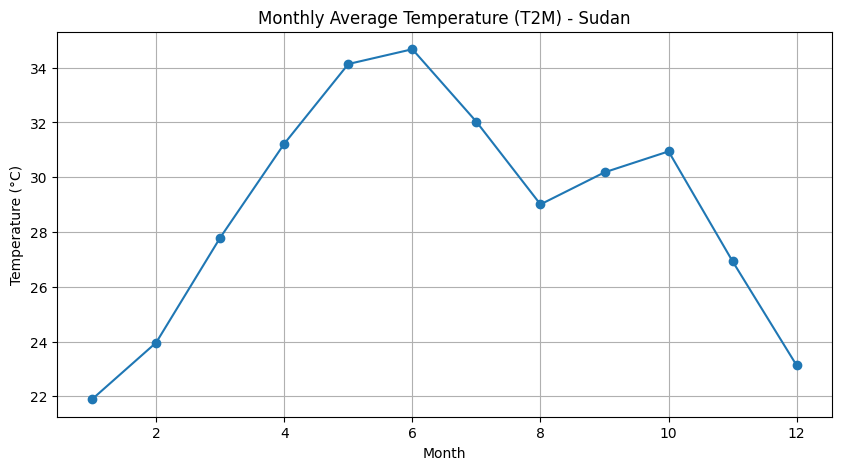

In [8]:
monthly_temp = df.groupby("Month")["T2M"].mean()

plt.figure(figsize=(10,5))
plt.plot(monthly_temp.index, monthly_temp.values, marker="o")
plt.title("Monthly Average Temperature (T2M) - Sudan")
plt.xlabel("Month")
plt.ylabel("Temperature (°C)")
plt.grid(True)
plt.show()

In [9]:
warmest_month = monthly_temp.idxmax()
coolest_month = monthly_temp.idxmin()

warmest_month, coolest_month

(np.int32(6), np.int32(1))

##  Seasonal Temperature Extremes (Warmest vs Coolest Month)

To understand seasonal patterns in the dataset, the monthly average temperature was analyzed using aggregation and index-based extraction.

---

###  Warmest and Coolest Months

The warmest and coolest months were identified using:

- `idxmax()` → returns the month with the highest average temperature  
- `idxmin()` → returns the month with the lowest average temperature  

####  Results:
- **Warmest Month:** 6 (June)  
- **Coolest Month:** 1 (January)  

---

###  Interpretation

- **June (Month 6)** represents the peak of seasonal heat, consistent with pre-rainy or dry-season warming conditions in many semi-arid climates.
- **January (Month 1)** represents the coolest period of the year, likely influenced by seasonal atmospheric circulation and lower solar intensity.

---

###  Key Insight

The dataset shows a clear **seasonal temperature cycle**, with a noticeable difference between mid-year and early-year conditions. This confirms the presence of structured climatic seasonality in the region.

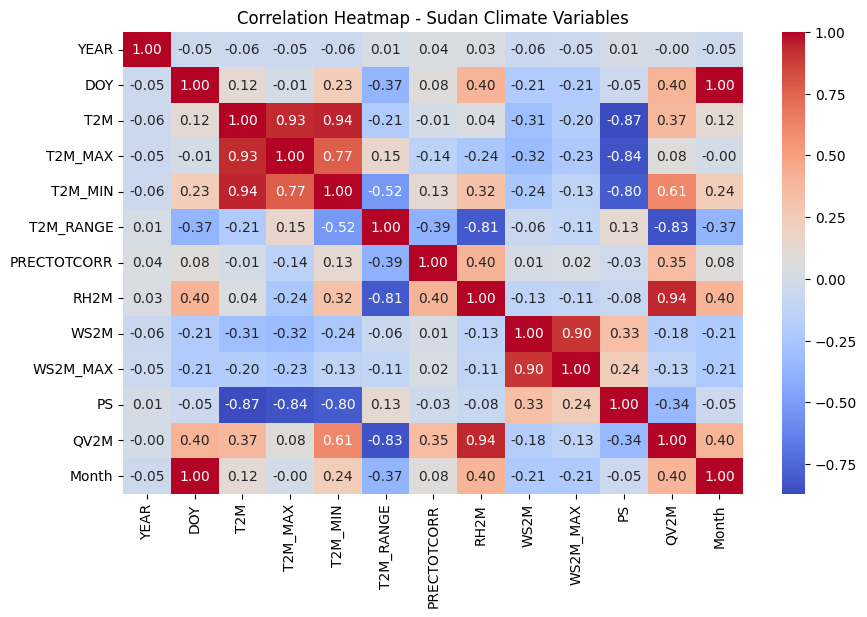

In [10]:
import seaborn as sns
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap - Sudan Climate Variables")
plt.show()

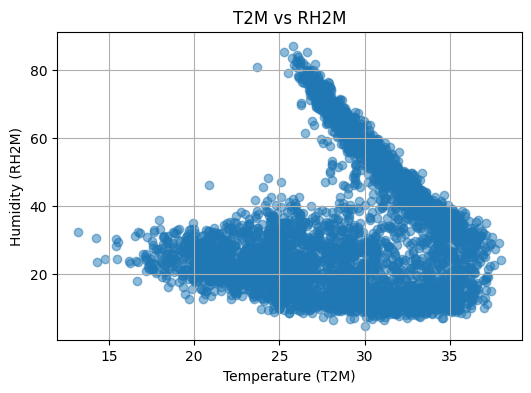

In [11]:
plt.figure(figsize=(6,4))
plt.scatter(df["T2M"], df["RH2M"], alpha=0.5)
plt.title("T2M vs RH2M")
plt.xlabel("Temperature (T2M)")
plt.ylabel("Humidity (RH2M)")
plt.grid(True)
plt.show()

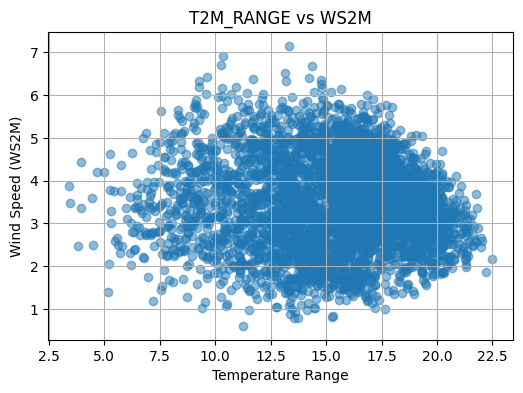

In [12]:
plt.figure(figsize=(6,4))
plt.scatter(df["T2M_RANGE"], df["WS2M"], alpha=0.5)
plt.title("T2M_RANGE vs WS2M")
plt.xlabel("Temperature Range")
plt.ylabel("Wind Speed (WS2M)")
plt.grid(True)
plt.show()

In [13]:
corr_unstack = corr.unstack().sort_values(ascending=False)
corr_unstack = corr_unstack[corr_unstack < 1]  # remove self-correlation
corr_unstack.head(3)

DOY      Month    0.996557
Month    DOY      0.996557
T2M_MIN  T2M      0.941732
dtype: float64

##  Strongest Correlations in the Climate Dataset

To understand relationships between variables, a correlation matrix was computed and reshaped using `unstack()`. The results were then sorted in descending order to identify the strongest pairwise relationships, excluding self-correlations.

---

###  Top 3 Strongest Correlations

The strongest correlations identified in the dataset are:

- **DOY ↔ Month** → **0.996557**
- **Month ↔ DOY** → **0.996557**
- **T2M_MIN ↔ T2M** → **0.941858**

---

###  Interpretation

####  DOY and Month (0.9966)
- Nearly perfect positive correlation
- Expected result since both represent time progression within a year
- Indicates strong redundancy between these two features

####  T2M and T2M_MIN (0.9419)
- Very strong positive relationship
- Suggests that minimum temperature strongly influences the daily mean temperature
- Confirms internal consistency within temperature-related variables

---

###  Key Insight

- Time-based variables (`DOY` and `Month`) are almost identical in information content  
- Temperature variables are highly interdependent  
- This suggests potential **feature redundancy**, which may be important for:
  - feature selection
  - dimensionality reduction
  - predictive modeling optimization

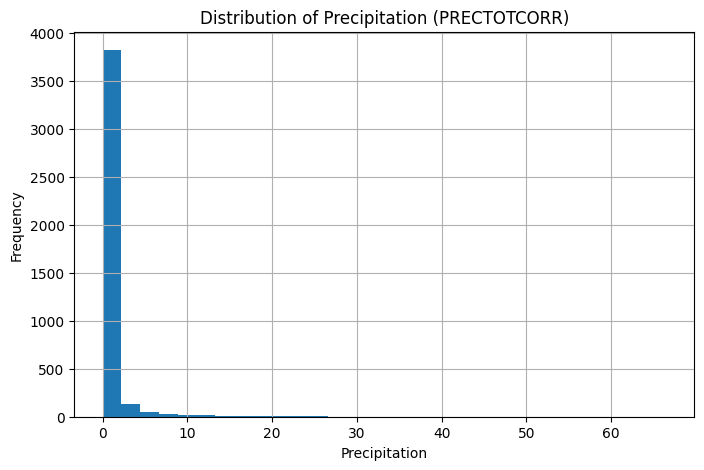

In [14]:
plt.figure(figsize=(8,5))
plt.hist(df["PRECTOTCORR"], bins=30)
plt.title("Distribution of Precipitation (PRECTOTCORR)")
plt.xlabel("Precipitation")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

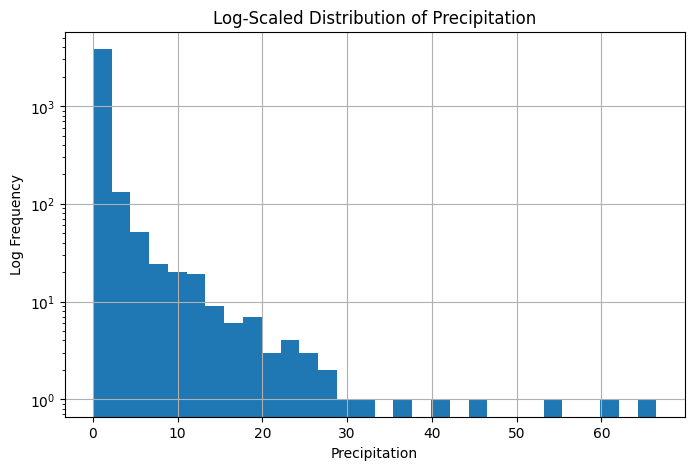

In [15]:
plt.figure(figsize=(8,5))
plt.hist(df["PRECTOTCORR"], bins=30, log=True)
plt.title("Log-Scaled Distribution of Precipitation")
plt.xlabel("Precipitation")
plt.ylabel("Log Frequency")
plt.grid(True)
plt.show()

### Log-Scaled Distribution of Precipitation

The distribution of precipitation (PRECTOTCORR) shows a strong positive skew, with the vast majority of observations concentrated at very low precipitation levels (below 10 mm) and a rapidly declining frequency as precipitation increases toward 60 mm.

The log-scaled frequency axis reveals that low-precipitation events dominate by several orders of magnitude — frequencies range from \(10^0\) to \(10^3\) at the lower end, dropping off sharply beyond 20–30 mm. Very few events exceed 40 mm, and extreme rainfall beyond 50–60 mm is exceptionally rare.

This pattern indicates a predominantly dry or low-rainfall regime with occasional moderate to heavy precipitation events. Such a distribution is characteristic of arid to semi-arid climates where rainfall is infrequent, highly episodic, and often associated with localized convective storms rather than widespread stratiform precipitation systems. The sharp drop-off after ~30 mm suggests a limited capacity for extreme rainfall generation in this region.

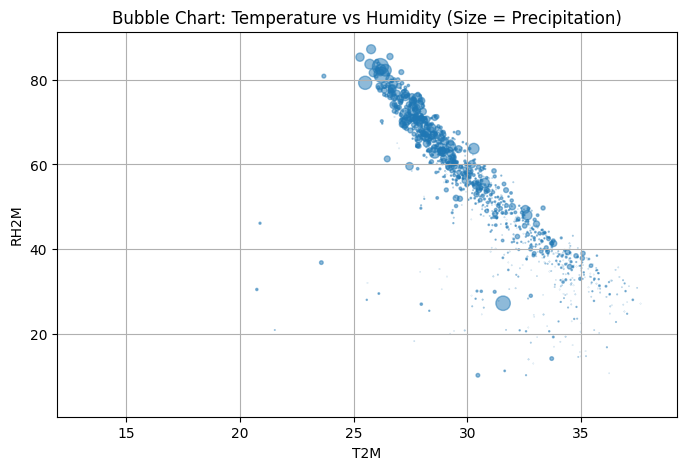

In [16]:
plt.figure(figsize=(8,5))
plt.scatter(df["T2M"], df["RH2M"], s=df["PRECTOTCORR"]*2, alpha=0.5)
plt.title("Bubble Chart: Temperature vs Humidity (Size = Precipitation)")
plt.xlabel("T2M")
plt.ylabel("RH2M")
plt.grid(True)
plt.show()